# 📥 KOSPI/KOSDAQ 전 종목 데이터 수집

**이 노트북의 역할:** 이후 모든 분석의 원재료가 되는 데이터를 한 번에 수집한다.

- KOSPI + KOSDAQ 전 종목 리스트 수집 (약 2,700개)
- 5년치 일별 OHLCV 데이터 병렬 다운로드
- `data/prices/` 폴더에 종목별 parquet 파일로 저장

**⏱ 예상 시간:** 전체 최초 다운로드 약 10~20분 (이후 재실행 시 캐시 사용으로 즉시)

In [1]:
# ─────────────────────────────────────────
# 환경 설정
# ─────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from src.data_collector import get_stock_list, download_all, load_stock

print('환경 설정 완료!')

환경 설정 완료!


In [2]:
# ─────────────────────────────────────────
# 1단계: 전 종목 리스트 수집
# ─────────────────────────────────────────
print('=== KOSPI + KOSDAQ 종목 리스트 수집 ===')
stock_list = get_stock_list(markets=('KOSPI', 'KOSDAQ'))

print(f'\n총 {len(stock_list):,}개 종목')

# 주요 컬럼만 추출해서 보기 좋게 출력
cols = [c for c in ['Code', 'Name', 'Market', 'CompanySize', 'MarketCap', 'Close'] 
        if c in stock_list.columns]
print(stock_list[cols].head(10).to_string(index=False))

=== KOSPI + KOSDAQ 종목 리스트 수집 ===
캐시에서 로드: 2770개 종목

총 2,770개 종목
  Code      Name Market   Close
005930      삼성전자  KOSPI  219500
000660    SK하이닉스  KOSPI 1222000
005935     삼성전자우  KOSPI  153700
373220  LG에너지솔루션  KOSPI  481000
005380       현대차  KOSPI  513000
402340     SK스퀘어  KOSPI  725000
034020   두산에너빌리티  KOSPI  127100
012450 한화에어로스페이스  KOSPI 1463000
207940  삼성바이오로직스  KOSPI 1528000
329180   HD현대중공업  KOSPI  671000


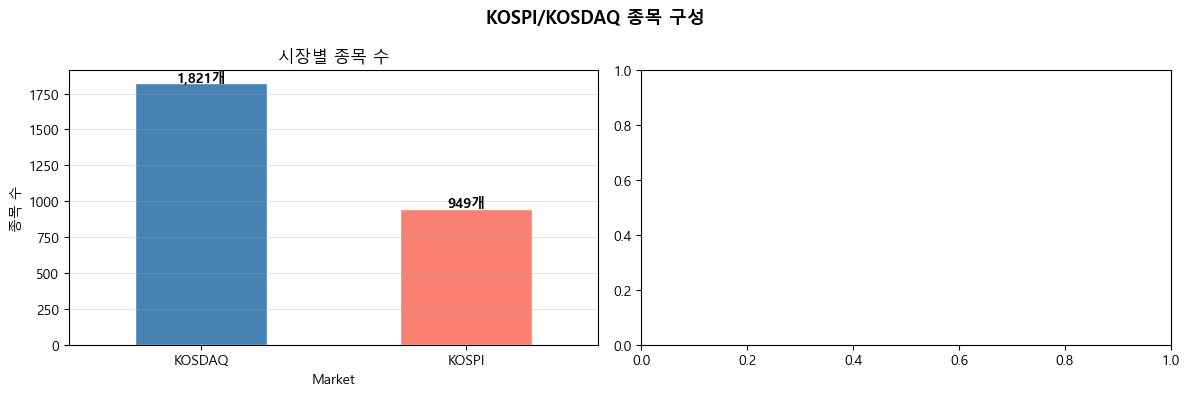

In [3]:
# 시장별 / 기업규모별 종목 수 시각화
market_counts = stock_list['Market'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 시장별 종목 수
market_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('시장별 종목 수')
axes[0].set_ylabel('종목 수')
axes[0].set_xticklabels(market_counts.index, rotation=0)
for i, v in enumerate(market_counts):
    axes[0].text(i, v + 10, f'{v:,}개', ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# 기업 규모별 종목 수
if 'CompanySize' in stock_list.columns:
    size_counts = stock_list['CompanySize'].value_counts().head(10).dropna()
    size_counts.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
    axes[1].set_title('기업 규모별 종목 수')
    axes[1].set_xlabel('종목 수')
    axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('KOSPI/KOSDAQ 종목 구성', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# 시가총액 상위 20개 종목 확인
if 'MarketCap' in stock_list.columns:
    top20 = stock_list.nlargest(20, 'MarketCap')[['Code', 'Name', 'Market', 'MarketCap', 'Close']].copy()
    top20['MarketCap_조'] = (top20['MarketCap'] / 1e12).round(1)  # 조원 단위
    print('=== 시가총액 상위 20개 종목 ===')
    print(top20[['Code', 'Name', 'Market', 'MarketCap_조', 'Close']].to_string(index=False))

In [5]:
# ─────────────────────────────────────────
# 2단계: 전 종목 가격 데이터 다운로드
# ─────────────────────────────────────────
# ※ 최초 실행 시 10~20분 소요
# ※ 이미 다운로드된 종목은 자동으로 스킵

print('=== 전 종목 가격 데이터 다운로드 시작 ===')
print('이미 저장된 종목은 스킵됩니다.\n')

result = download_all(
    start='2019-01-01',
    end='2025-12-31',
    max_workers=6  # 동시 다운로드 수 (높이면 빠르지만 서버 차단 위험)
)

print(f'\n성공: {result["success"]}개 / 실패: {result["fail"]}개')

=== 전 종목 가격 데이터 다운로드 시작 ===
이미 저장된 종목은 스킵됩니다.

캐시에서 로드: 2770개 종목
전체: 2770개  이미 저장됨: 2731개  다운로드 필요: 39개


다운로드 중: 100%|██████████████████████████████████████████████████| 39/39 [00:10<00:00,  3.65종목/s, 성공=0, 실패=39]/종목]


완료  성공: 2731  실패: 39

성공: 2731개 / 실패: 39개


=== 저장된 데이터 현황 ===
종목 수: 2,731개
평균 거래일: 1487일
최소 거래일: 21일
최대 거래일: 1719일


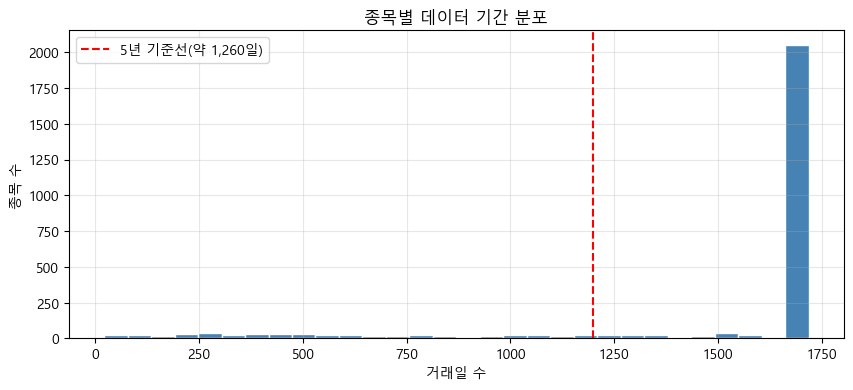

In [6]:
# ─────────────────────────────────────────
# 3단계: 다운로드 결과 검증
# ─────────────────────────────────────────

price_dir = '../data/prices'
files = [f for f in os.listdir(price_dir) if f.endswith('.parquet')]

# 각 파일의 데이터 길이 확인
day_counts = []
for f in files:
    try:
        df = pd.read_parquet(os.path.join(price_dir, f))
        day_counts.append(len(df))
    except:
        pass

day_series = pd.Series(day_counts)
print('=== 저장된 데이터 현황 ===')
print(f'종목 수: {len(files):,}개')
print(f'평균 거래일: {day_series.mean():.0f}일')
print(f'최소 거래일: {day_series.min()}일')
print(f'최대 거래일: {day_series.max()}일')

plt.figure(figsize=(10, 4))
plt.hist(day_series, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('거래일 수')
plt.ylabel('종목 수')
plt.title('종목별 데이터 기간 분포')
plt.axvline(x=1200, color='red', linestyle='--', label='5년 기준선(약 1,260일)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

삼성전자 데이터:
기간: 2019-01-02 ~ 2025-12-30
거래일: 1719일
              Open    High     Low   Close    Volume    Change
Date                                                          
2025-12-23  110900  112500  110400  111500  20419187  0.009050
2025-12-24  112400  112400  110900  111100  12492939 -0.003587
2025-12-26  112400  117000  112400  117000  34018174  0.053105
2025-12-29  119400  119700  118200  119500  19676004  0.021368
2025-12-30  119100  121200  118700  119900  19746349  0.003347


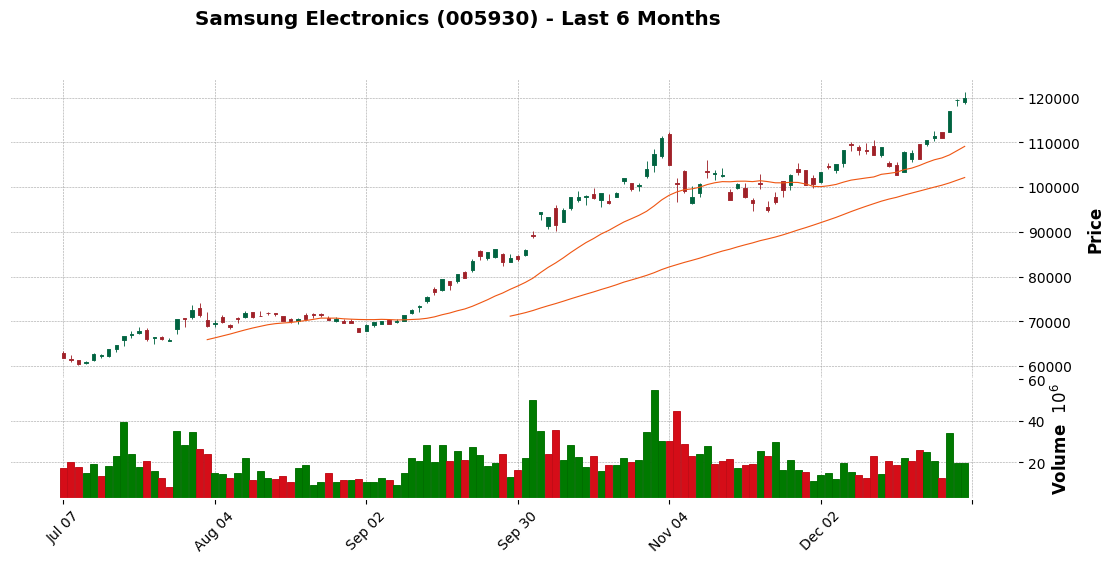


데이터 수집 완료! 다음: 02_market_overview.ipynb


In [7]:
# ─────────────────────────────────────────
# 4단계: 단일 종목 데이터 샘플 확인
# ─────────────────────────────────────────
import mplfinance as mpf

samsung = load_stock('005930')

print('삼성전자 데이터:')
print(f'기간: {samsung.index[0].date()} ~ {samsung.index[-1].date()}')
print(f'거래일: {len(samsung)}일')
print(samsung.tail(5))

# 최근 6개월 캔들 차트
recent = samsung.tail(120)
mpf.plot(recent, type='candle', style='charles',
         title='Samsung Electronics (005930) - Last 6 Months',
         volume=True, figsize=(14, 6),
         mav=(20, 60))

print('\n데이터 수집 완료! 다음: 02_market_overview.ipynb')